<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Reconstruction losses

In [0]:
#| echo: false
#| output: asis
show_doc(MSELoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L50){target="_blank" style="float:right; font-size:smaller"}

### MSELoss

```python

def MSELoss(
    inp:Any, targ:Any
)->Tensor:


```

In [0]:
#| echo: false
#| output: asis
show_doc(L1Loss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L59){target="_blank" style="float:right; font-size:smaller"}

### L1Loss

```python

def L1Loss(
    inp:Any, targ:Any
)->Tensor:


```

In [ ]:
#| echo: false
#| output: asis
show_doc(SSIMLoss)

---

### SSIMLoss

```python

def SSIMLoss(
    spatial_dims:int, data_range:float=1.0, kernel_type:KernelType | str=gaussian, win_size:int | Sequence[int]=11,
    kernel_sigma:float | Sequence[float]=1.5, k1:float=0.01, k2:float=0.03, reduction:LossReduction | str=mean
):


```

*Compute the loss function based on the Structural Similarity Index Measure (SSIM) Metric.*

For more info, visit
    https://vicuesoft.com/glossary/term/ssim-ms-ssim/

SSIM reference paper:
    Wang, Zhou, et al. "Image quality assessment: from error visibility to structural
    similarity." IEEE transactions on image processing 13.4 (2004): 600-612.

In [ ]:
#| echo: false
#| output: asis
show_doc(PerceptualLoss)

---

### PerceptualLoss

```python

def PerceptualLoss(
    spatial_dims:int, network_type:str=alex, is_fake_3d:bool=True, fake_3d_ratio:float=0.5,
    cache_dir:str | None=None, pretrained:bool=True, pretrained_path:str | None=None,
    pretrained_state_dict_key:str | None=None, channel_wise:bool=False
):


```

*Perceptual loss using features from pretrained deep neural networks trained. The function supports networks*
pretrained on: ImageNet that use the LPIPS approach from Zhang, et al. "The unreasonable effectiveness of deep
features as a perceptual metric." https://arxiv.org/abs/1801.03924 ; RadImagenet from Mei, et al. "RadImageNet: An
Open Radiologic Deep Learning Research Dataset for Effective Transfer Learning"
https://pubs.rsna.org/doi/full/10.1148/ryai.210315 ; MedicalNet from Chen et al. "Med3D: Transfer Learning for
3D Medical Image Analysis" https://arxiv.org/abs/1904.00625 ;
and ResNet50 from Torchvision: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html .

The fake 3D implementation is based on a 2.5D approach where we calculate the 2D perceptual loss on slices from all
three axes and average. The full 3D approach uses a 3D network to calculate the perceptual loss.
MedicalNet networks are only compatible with 3D inputs and support channel-wise loss.

Args:
    spatial_dims: number of spatial dimensions.
    network_type: {``"alex"``, ``"vgg"``, ``"squeeze"``, ``"radimagenet_resnet50"``,
    ``"medicalnet_resnet10_23datasets"``, ``"medicalnet_resnet50_23datasets"``, ``"resnet50"``}
        Specifies the network architecture to use. Defaults to ``"alex"``.
    is_fake_3d: if True use 2.5D approach for a 3D perceptual loss.
    fake_3d_ratio: ratio of how many slices per axis are used in the 2.5D approach.
    cache_dir: path to cache directory to save the pretrained network weights.
    pretrained: whether to load pretrained weights. This argument only works when using networks from
        LIPIS or Torchvision. Defaults to ``"True"``.
    pretrained_path: if `pretrained` is `True`, users can specify a weights file to be loaded
        via using this argument. This argument only works when ``"network_type"`` is "resnet50".
        Defaults to `None`.
    pretrained_state_dict_key: if `pretrained_path` is not `None`, this argument is used to
        extract the expected state dict. This argument only works when ``"network_type"`` is "resnet50".
        Defaults to `None`.
    channel_wise: if True, the loss is returned per channel. Otherwise the loss is averaged over the channels.
            Defaults to ``False``.

### Fourier Ring Correlation

In [0]:
#| echo: false
#| output: asis
show_doc(radial_mask)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L73){target="_blank" style="float:right; font-size:smaller"}

### radial_mask

```python

def radial_mask(
    r, cx, cy, sx, sy, delta:int=1
):


```

*Create a radial ring mask.*

In [0]:
#| echo: false
#| output: asis
show_doc(get_fourier_ring_correlations)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L91){target="_blank" style="float:right; font-size:smaller"}

### get_fourier_ring_correlations

```python

def get_fourier_ring_correlations(
    image1, image2
):


```

*Compute Fourier Ring Correlation curve.*

In [0]:
#| echo: false
#| output: asis
show_doc(FCRCutoff)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L148){target="_blank" style="float:right; font-size:smaller"}

### FCRCutoff

```python

def FCRCutoff(
    image1, image2, threshold:float=0.14285714285714285, plot:bool=False
):


```

*Frequency where FRC drops below a threshold.*

Args:
    image1:
        First input image.

    image2:
        Second input image.

    threshold:
        FRC cutoff threshold.

    plot:
        If True, plots the FRC curve and cutoff point.

Returns:
    float:
        Cutoff frequency.

In [0]:
#| echo: false
#| output: asis
show_doc(FRCLoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L222){target="_blank" style="float:right; font-size:smaller"}

### FRCLoss

```python

def FRCLoss(
    image1, image2
):


```

*FRC loss defined as:*
1 - mean correlation over frequencies

FRC Loss: 0.8165


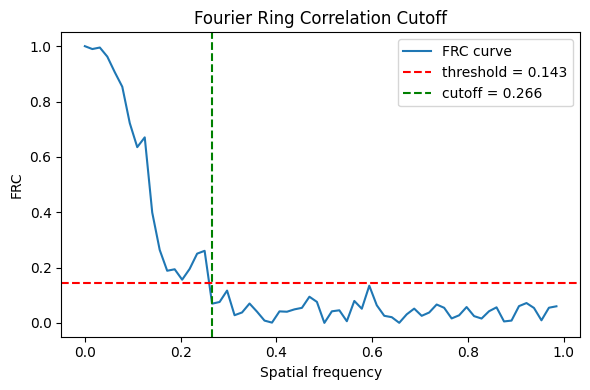

In [ ]:
def test_frc():
    """
    Simple sanity test for FRC + FRCLoss.
    """

    # ---------------------------------
    # 1. Create synthetic images
    # ---------------------------------
    size = 128

    x = torch.linspace(-1, 1, size)
    y = torch.linspace(-1, 1, size)
    xx, yy = torch.meshgrid(x, y, indexing="xy")

    # Base image: smooth Gaussian
    img1 = torch.exp(-(xx**2 + yy**2))

    # Slightly degraded version (blur + noise)
    noise = 0.05 * torch.randn_like(img1)
    img2 = torch.exp(-(xx**2 + yy**2) * 1.2) + noise

    img1 = img1.float()
    img2 = img2.float()

    # ---------------------------------
    # 2. Compute FRC
    # ---------------------------------
    frc, freq = get_fourier_ring_correlations(img1, img2)

    # ---------------------------------
    # 3. Compute loss
    # ---------------------------------
    loss = FRCLoss(img1, img2)
    print(f"FRC Loss: {loss.item():.4f}")

    test_eq(loss, 1.0 - frc.mean())

    # ---------------------------------
    # 4. Plot
    # ---------------------------------
    FCRCutoff(img1, img2, threshold=1/7, plot=True)


# Run test
test_frc()

## Combined Losses

In [0]:
#| echo: false
#| output: asis
show_doc(CombinedLoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L234){target="_blank" style="float:right; font-size:smaller"}

### CombinedLoss

```python

def CombinedLoss(
    spatial_dims:int=2, # Number of spatial dimensions (2 for 2D images, 3 for 3D images)
    mse_weight:float=0.33, # Weight for the MSE loss component
    mae_weight:float=0.33, # Weight for the MAE loss component
):


```

*CombinedLoss computes a weighted combination of SSIM, MSE, and MAE losses.*

This class allows for the combination of three different loss functions:
Structural Similarity Index (SSIM), Mean Squared Error (MSE), and Mean Absolute Error (MAE).
The weights for MSE and MAE can be adjusted, and the weight for SSIM is automatically 
calculated as the remaining weight.

CombinedLoss reference paper:
Shah, Z. H., Müller, M., Hammer, B., Huser, T., & Schenck, W. (2022, July). 
Impact of different loss functions on denoising of microscopic images. 
In 2022 International Joint Conference on Neural Networks (IJCNN) (pp. 1-10). IEEE.

In [0]:
#| echo: false
#| output: asis
show_doc(MSSSIMLoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L265){target="_blank" style="float:right; font-size:smaller"}

### MSSSIMLoss

```python

def MSSSIMLoss(
    spatial_dims:int=2, # Number of spatial dimensions (2 for 2D images, 3 for 3D images).
    window_size:int=8, # Size of the Gaussian filter for SSIM.
    sigma:float=1.5, # Standard deviation of the Gaussian filter.
    reduction:str='mean', # Specifies the reduction to apply to the output ('mean', 'sum', or 'none').
    levels:int=3, # Number of scales to use for MS-SSIM.
    weights:NoneType=None, # Weights to apply to each scale. If None, default values are used.
):


```

*Multi-Scale Structural Similarity (MSSSIM) Loss using MONAI's SSIMLoss as the base.*

In [ ]:
# Test MSSSIMLoss & SSIMLoss
batch_size, channels, height, width = 2, 1, 128, 128
input_tensor = torch.randn(batch_size, channels, height, width)
target_tensor = torch.randn(batch_size, channels, height, width)

msssim_loss = MSSSIMLoss(spatial_dims=2, levels=3)
ssim_loss = SSIMLoss(spatial_dims=2)

loss_msssim = msssim_loss(input_tensor, target_tensor)
loss_ssim = ssim_loss(input_tensor, target_tensor)

# Both should return scalar tensors
test_is(loss_msssim.dim(), 0) # MS-SSIM loss should return a scalar
test_is(loss_ssim.dim(), 0) #SSIM loss should return a scalar

In [0]:
#| echo: false
#| output: asis
show_doc(MSSSIML1Loss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L322){target="_blank" style="float:right; font-size:smaller"}

### MSSSIML1Loss

```python

def MSSSIML1Loss(
    spatial_dims:int=2, # Number of spatial dimensions.
    alpha:float=0.025, # Weighting factor between MS-SSIM and L1 loss.
    window_size:int=8, # Size of the Gaussian filter for SSIM.
    sigma:float=1.5, # Standard deviation of the Gaussian filter.
    reduction:str='mean', # Specifies the reduction to apply to the output ('mean', 'sum', or 'none').
    levels:int=3, # Number of scales to use for MS-SSIM.
    weights:NoneType=None, # Weights to apply to each scale. If None, default values are used.
):


```

*Multi-Scale Structural Similarity (MSSSIM) with Gaussian-weighted L1 Loss.*

Reference paper:
Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016). 
Loss functions for image restoration with neural networks. 
IEEE Transactions on computational imaging, 3(1), 47-57.

In [ ]:
msssiml1_loss = MSSSIML1Loss(alpha=0.025, window_size=11, sigma=1.5, levels=3)
input_image = torch.randn(4, 1, 128, 128)  # Batch of 4 grayscale images (1 channel)
target_image = torch.randn(4, 1, 128, 128)

# Compute MSSSIM + Gaussian-weighted L1 loss
loss = msssiml1_loss(input_image, target_image)
loss2 = ssim_loss(input_image, target_image)
print("ms-ssim: ", loss, '\nssim: ', loss2)

test_is(loss.dim(), 0)
test_is(loss2.dim(), 0)

ms-ssim:  tensor(0.0247) 
ssim:  tensor(0.9954)


In [0]:
#| echo: false
#| output: asis
show_doc(MSSSIML2Loss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L412){target="_blank" style="float:right; font-size:smaller"}

### MSSSIML2Loss

```python

def MSSSIML2Loss(
    spatial_dims:int=2, # Number of spatial dimensions.
    alpha:float=0.1, # Weighting factor between MS-SSIM and L2 loss.
    window_size:int=11, # Size of the Gaussian window for SSIM.
    sigma:float=1.5, # Standard deviation of the Gaussian.
    reduction:str='mean', # Specifies the reduction to apply to the output ('mean', 'sum', or 'none').
    levels:int=3, # Number of scales to use for MS-SSIM.
    weights:NoneType=None, # Weights to apply to each scale. If None, default values are used.
):


```

*Multi-Scale Structural Similarity (MSSSIM) with Gaussian-weighted L2 Loss.*

Reference paper:
Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016). 
Loss functions for image restoration with neural networks. 
IEEE Transactions on computational imaging, 3(1), 47-57.

In [ ]:
msssim_l2_loss = MSSSIML2Loss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
output = torch.rand(10, 3, 64, 64).to(device)  # Example output with even dimensions
target = torch.rand(10, 3, 64, 64).to(device)  # Example target with even dimensions
loss = msssim_l2_loss(output, target)
print(loss)

test_is(loss.dim(), 0)

tensor(0.0935, device='cuda:0')


In [0]:
#| echo: false
#| output: asis
show_doc(CellLoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L501){target="_blank" style="float:right; font-size:smaller"}

### CellLoss

```python

def CellLoss(
    
):


```

*Combined classification and regression loss for cell prediction tasks.*

The first column of `pred`/`targ` is treated as a binary classification
logit (cell presence), while the remaining columns are treated as
continuous regression targets.

The total loss is computed as:

    0.5 * MSE(pred[:, 1:], 5 * targ[:, 1:]) +
    BCEWithLogitsLoss(pred[:, 0], targ[:, 0])

Attributes:
    MSE_loss (nn.MSELoss): Mean squared error loss for regression targets.
    BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits
        for cell presence prediction.

Reference paper:
    Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021). 
    Cellpose: a generalist algorithm for cellular segmentation. 
    Nature methods, 18(1), 100-106.

In [0]:
#| echo: false
#| output: asis
show_doc(InstanceSegLoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L540){target="_blank" style="float:right; font-size:smaller"}

### InstanceSegLoss

```python

def InstanceSegLoss(
    mse_weight:float=0.5, # Weight applied to the MSE component
    ssim_weight:float=1.0, # Weight applied to the SSIM component
    spatial_dims:int=2, # Number of spatial dimensions (2 for 2D, 3 for 3D)
    logits:bool=True, # Whether to apply sigmoid to logits before computing loss
):


```

*Combined Binary Cross-Entropy and Mean Squared Error loss*
for multi-channel instance segmentation tasks.

All channels of `pred`/`targ` are treated as independent binary
instance masks. Each channel represents one object instance.

The total loss is computed as:

    BCEWithLogitsLoss(sigmoid(pred), targ) +
    mse_weight * MSE(pred, targ) +
    ssim_weight * SSIMLoss(pred, targ)

Binary Cross-Entropy provides stable pixel-wise supervision,
while the MSE term penalizes probability deviations and can
encourage smoother mask predictions.

Attributes:
    BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits.
    MSE_loss (nn.MSELoss): Mean squared error loss applied to probabilities.
    mse_weight (float): Weight applied to the MSE component.

This is a variation on CellLoss proposed in:
    Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021). 
    Cellpose: a generalist algorithm for cellular segmentation. 
    Nature methods, 18(1), 100-106.

In [0]:
#| echo: false
#| output: asis
show_doc(DiceBCELoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L601){target="_blank" style="float:right; font-size:smaller"}

### DiceBCELoss

```python

def DiceBCELoss(
    dice_weight:float=1.0, # Weight applied to Dice component
    smooth:float=1e-06, # Smoothing constant for Dice stability
):


```

*Hybrid Binary Cross-Entropy + Dice loss for multi-channel instance segmentation.*

All channels of `pred`/`targ` are treated as independent binary
instance masks. Each channel represents one object instance.

The total loss is computed as:

    BCEWithLogitsLoss(pred, targ) +
    dice_weight * DiceLoss(sigmoid(pred), targ)

where DiceLoss is defined as:

    1 - (2 * intersection + smooth) / (union + smooth)

This formulation improves stability (BCE) while directly optimizing
overlap quality (Dice), which is particularly beneficial for
imbalanced foreground/background segmentation tasks.

Attributes:
    BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits.
    dice_weight (float): Weight applied to the Dice loss component.
    smooth (float): Smoothing constant to avoid division by zero.

## Segmentation losses

In [ ]:
#| echo: false
#| output: asis
show_doc(DiceLoss)

---

### DiceLoss

```python

def DiceLoss(
    include_background:bool=True, to_onehot_y:bool=False, sigmoid:bool=False, softmax:bool=False,
    other_act:Callable | None=None, squared_pred:bool=False, jaccard:bool=False, reduction:LossReduction | str=mean,
    smooth_nr:float=1e-05, smooth_dr:float=1e-05, batch:bool=False,
    weight:Sequence[float] | float | int | torch.Tensor | None=None, soft_label:bool=False
)->None:


```

*Compute average Dice loss between two tensors. It can support both multi-classes and multi-labels tasks.*
The data `input` (BNHW[D] where N is number of classes) is compared with ground truth `target` (BNHW[D]).

Note that axis N of `input` is expected to be logits or probabilities for each class, if passing logits as input,
must set `sigmoid=True` or `softmax=True`, or specifying `other_act`. And the same axis of `target`
can be 1 or N (one-hot format).

The `smooth_nr` and `smooth_dr` parameters are values added to the intersection and union components of
the inter-over-union calculation to smooth results respectively, these values should be small.

The original papers:

    Milletari, F. et. al. (2016) V-Net: Fully Convolutional Neural Networks for Volumetric
    Medical Image Segmentation. 3DV 2016.

    Wang, Z. et. al. (2023) Jaccard Metric Losses: Optimizing the Jaccard Index with
    Soft Labels. NeurIPS 2023.

    Wang, Z. et. al. (2023) Dice Semimetric Losses: Optimizing the Dice Score with
    Soft Labels. MICCAI 2023.

In [0]:
#| echo: false
#| output: asis
show_doc(activation)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L675){target="_blank" style="float:right; font-size:smaller"}

### activation

```python

def activation(
    x
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(CrossEntropyLossFlat3D)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L679){target="_blank" style="float:right; font-size:smaller"}

### CrossEntropyLossFlat3D

```python

def CrossEntropyLossFlat3D(
    args:VAR_POSITIONAL, axis:int=-1, # Class axis
    weight:NoneType=None, ignore_index:int=-100, reduction:str='mean',
    flatten:bool=True, # Flatten `inp` and `targ` before calculating loss
    floatify:bool=False, # Convert `targ` to `float`
    is_2d:bool=True, # Whether `flatten` keeps one or two channels when applied
):


```

*Same as `nn.CrossEntropyLoss`, but flattens input and target for 3D inputs.*

In [0]:
#| echo: false
#| output: asis
show_doc(BCELoss)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/losses.py#L695){target="_blank" style="float:right; font-size:smaller"}

### BCELoss

```python

def BCELoss(
    
):


```

*Multi-channel binary instance segmentation loss.*

All channels of `pred`/`targ` are treated as independent binary
instance masks. Each channel represents one object instance and
is trained using Binary Cross-Entropy with Logits.

The total loss is computed as:

    BCEWithLogitsLoss(pred, targ)

This formulation is appropriate for multi-label instance segmentation
where instances may overlap and predictions are raw logits.

Attributes:
    BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits
    applied independently across all channels and pixels.

In [ ]:
# inputs and targets must be equally dimensional tensors
from torch import randn, randint

In [ ]:
inputs = randn((1, 1, 256, 256))  # Input
targets = randint(0, 2, (1, 1, 256, 256)).float()  # Ground Truth

# Initialize
dice_loss = DiceLoss()

# Compute loss
loss = dice_loss(inputs, targets)
print('Dice Loss:', loss.item())

test_is(loss.dim(), 0)

Dice Loss: 0.49998021125793457


## Registration losses

In [ ]:
#| echo: false
#| output: asis
show_doc(BendingEnergyLoss)

---

### BendingEnergyLoss

```python

def BendingEnergyLoss(
    normalize:bool=False, reduction:LossReduction | str=mean
)->None:


```

*Calculate the bending energy based on second-order differentiation of ``pred`` using central finite difference.*

For more information,
see https://github.com/Project-MONAI/tutorials/blob/main/modules/bending_energy_diffusion_loss_notes.ipynb.

Adapted from:
    DeepReg (https://github.com/DeepRegNet/DeepReg)